# Introduction 

YouTube comment sections are often targeted by spam messages containing promotional links, misleading content, or repeated phrases. Manual moderation is inefficient due to the volume and diversity of comments.

This project investigates the effectiveness of machine learning techniques for detecting spam comments using the YouTube Spam Collection dataset from the UCI Machine Learning Repository. Both unsupervised learning and supervised learning approaches are applied to explore patterns in comment text and to build predictive spam classifiers.

# Objectives
- To build supervised models for spam classification
- To compare model performance across different YouTube datasets
- To evaluate models using appropriate classification metrics


# Dataset

The YouTube Spam Collection consists of five datasets, each representing comments from different YouTube channels. Each comment is labeled as spam (1) or non-spam/ ham (0).

### Dataset information
| Dataset | YouTube ID | # Spam | # Ham | Total | 
|-----------|---------------|-------|------|------| 
| Psy | 9bZkp7q19f0 | 175 | 175 | 350 |  
| KatyPerry | CevxZvSJLk8 | 175 | 175 | 350 |  
| LMFAO | KQ6zr6kCPj8 | 236 | 202 | 438 |  
| Eminem | uelHwf8o7_U | 245 | 203 | 448 |  
| Shakira |pRpeEdMmmQ0 | 174 | 196 | 370 |  

### Structure
1. Data Cleaning
2. EDA
3. Text Preprocessing
4. Model Building
5. Evaluation
6. Improvement
7. Website

In [87]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
from wordcloud import WordCloud
from pathlib import Path
from collections import Counter
import string
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
import warnings
warnings.filterwarnings('ignore')

print("Libraries are loaded")

Libraries are loaded


### Loading dataset and brief overview

In [ ]:
data_dir = Path("data")

datasets = {}
file_mappings = {
    'Psy': 'Youtube01-Psy.csv',
    'KatyPerry': 'Youtube02-KatyPerry.csv', 
    'LMFAO': 'Youtube03-LMFAO.csv',
    'Eminem': 'Youtube04-Eminem.csv',
    'Shakira': 'Youtube05-Shakira.csv'
}

print("Loading datasets...\n")
for artist, filename in file_mappings.items():
    file_path = data_dir / filename
    datasets[artist] = pd.read_csv(file_path)
    print(f"Dataset: {artist}")
    print("Shape:", datasets[artist].shape)
    print("Class distribution:")
    print(datasets[artist]['CLASS'].value_counts(normalize=True))
    print("Average comment length:", datasets[artist]['CONTENT'].apply(len).mean())
    print(f"Missing value;\n{datasets[artist].isnull().sum()}")
    print(f"Duplicate value {datasets[artist]['CONTENT'].duplicated().sum()}")
    print("-"*40)
    print()

Loading datasets...

Dataset: Psy
Shape: (350, 5)
Class distribution:
CLASS
1    0.5
0    0.5
Name: proportion, dtype: float64
Average comment length: 86.88571428571429
Missing value;
COMMENT_ID    0
AUTHOR        0
DATE          0
CONTENT       0
CLASS         0
dtype: int64
Duplicate value 1
----------------------------------------

Dataset: KatyPerry
Shape: (350, 5)
Class distribution:
CLASS
1    0.5
0    0.5
Name: proportion, dtype: float64
Average comment length: 107.36857142857143
Missing value;
COMMENT_ID    0
AUTHOR        0
DATE          0
CONTENT       0
CLASS         0
dtype: int64
Duplicate value 2
----------------------------------------

Dataset: LMFAO
Shape: (438, 5)
Class distribution:
CLASS
1    0.538813
0    0.461187
Name: proportion, dtype: float64
Average comment length: 60.81050228310502
Missing value;
COMMENT_ID    0
AUTHOR        0
DATE          0
CONTENT       0
CLASS         0
dtype: int64
Duplicate value 98
----------------------------------------

Dataset: Em

In [3]:
for key, df in datasets.items():
    duplicates = df[df['CONTENT'].duplicated()]
    print(f"Duplicates comment in dataset {key} with total {len(duplicates)} rows:")
    print(duplicates[["CONTENT", "CLASS"]])
    print("-"*100)

Duplicates comment in dataset Psy with total 1 rows:
                                               CONTENT  CLASS
126  PSY - GANGNAM STYLE (강남스타일) M/V: http://youtu....      0
----------------------------------------------------------------------------------------------------
Duplicates comment in dataset KatyPerry with total 2 rows:
                                               CONTENT  CLASS
211  Katy Perry - Roar (Official): http://youtu.be/...      0
306  Katy Perry - Roar (Official): http://youtu.be/...      0
----------------------------------------------------------------------------------------------------
Duplicates comment in dataset LMFAO with total 98 rows:
                                               CONTENT  CLASS
56                   Check out this video on YouTube:﻿      1
61              Love this song makes me wanna dance! ﻿      0
62              Love this song makes me wanna dance! ﻿      0
75                   Check out this video on YouTube:﻿      1
84        

In [4]:
for key, df in datasets.items():
    # 1. See how many times the same thing was said
    print(f"Top 5 most repeated comments for {key}:")
    print(df['CONTENT'].value_counts().head(5))

    # 2. Drop the exact duplicates, but keep ONE copy so the model learns it
    df = df.drop_duplicates(subset=['CONTENT'], keep='first').reset_index(drop=True)

    print(f"\nRemaining comments: {len(df)}")
    print("-"*100)
    print()


Top 5 most repeated comments for Psy:
CONTENT
PSY - GANGNAM STYLE (강남스타일) M/V: http://youtu.be/9bZkp7q19f0﻿                         2
me shaking my sexy ass on my channel enjoy ^_^ ﻿                                      1
watch?v=vtaRGgvGtWQ   Check this out .﻿                                               1
Hey, check out my new website!! This site is about kids stuff. kidsmediausa  . com    1
Subscribe to my channel ﻿                                                             1
Name: count, dtype: int64

Remaining comments: 349
----------------------------------------------------------------------------------------------------

Top 5 most repeated comments for KatyPerry:
CONTENT
Katy Perry - Roar (Official): http://youtu.be/CevxZvSJLk8﻿                                                                                                       3
http://psnboss.com/?ref=2tGgp3pV6L this is the song﻿                                                                                              

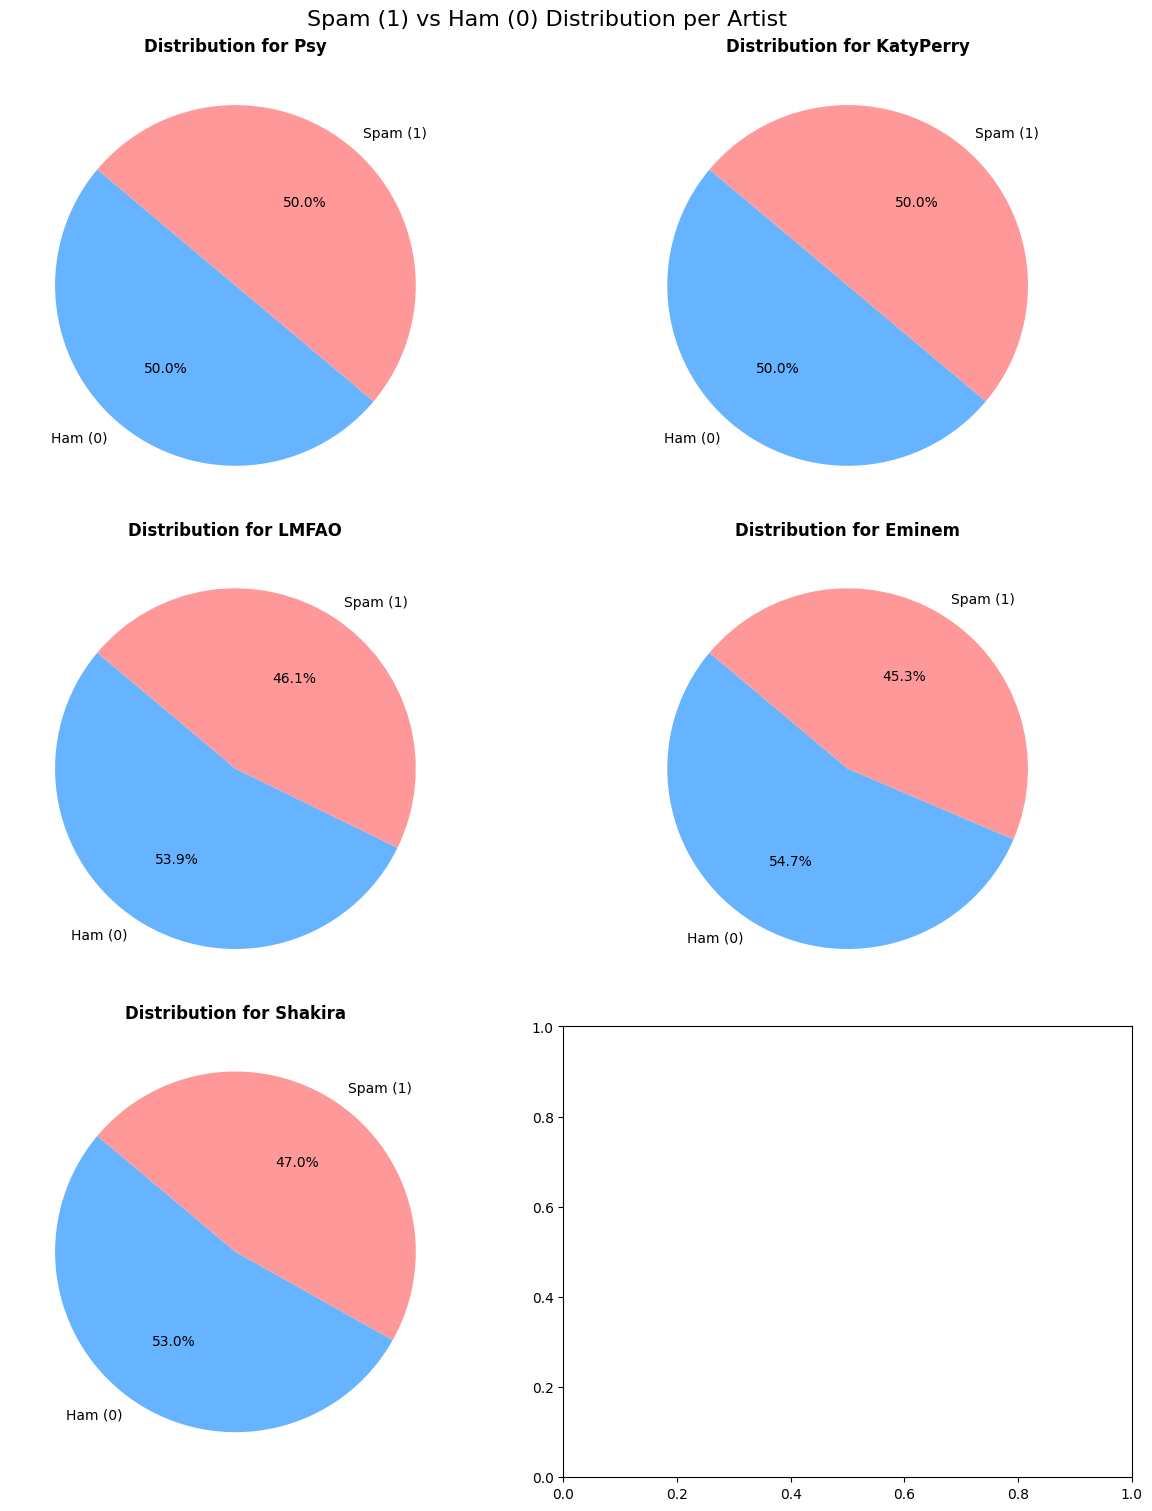

In [ ]:
fig, ax = plt.subplots(3, 2, figsize=(12, 15), constrained_layout=True)

# Use flatten() to make it easier to loop through ax instead of i//2, i%2
axes = ax.flatten()

for i, (artist, df) in enumerate(datasets.items()):
    counts = df['CLASS'].value_counts()
    labels = ['Ham (0)', 'Spam (1)']
    
    axes[i].pie(counts, labels=labels, autopct='%1.1f%%', startangle=140, colors=['#66b3ff','#ff9999'])
    axes[i].set_title(f'Distribution for {artist}', fontsize=12, fontweight='bold')

fig.suptitle('Spam (1) vs Ham (0) Distribution per Artist', fontsize=16)
plt.show()

In [ ]:
for artist, df in datasets.items():
    print(f"Overall class distribution for {artist}:")
    print(df['CLASS'].value_counts())
    print(f'Percentage of spam comments: {df["CLASS"][df["CLASS"]==1].count() / df["CLASS"].count() * 100:.2f}%')
    print()

Overall class distribution for Psy:
CLASS
1    175
0    175
Name: count, dtype: int64
Percentage of spam comments: 50.00%

Overall class distribution for KatyPerry:
CLASS
1    175
0    175
Name: count, dtype: int64
Percentage of spam comments: 50.00%

Overall class distribution for LMFAO:
CLASS
1    236
0    202
Name: count, dtype: int64
Percentage of spam comments: 53.88%

Overall class distribution for Eminem:
CLASS
1    245
0    203
Name: count, dtype: int64
Percentage of spam comments: 54.69%

Overall class distribution for Shakira:
CLASS
0    196
1    174
Name: count, dtype: int64
Percentage of spam comments: 47.03%



### Dataset selection

In [7]:
available_artists = list(datasets.keys())
print(f"Available datasets: {available_artists}")

# Change this list if you only want to analyze specific artists
# For now, we select ALL to ensure the most robust analysis
selected_artists = ['Psy', 'KatyPerry', 'LMFAO', 'Eminem', 'Shakira']

# Filter our dictionary to keep only the selected ones
datasets_selected = {name: datasets[name] for name in selected_artists}

print(f"Proceeding with {len(datasets_selected)} datasets.")

Available datasets: ['Psy', 'KatyPerry', 'LMFAO', 'Eminem', 'Shakira']
Proceeding with 5 datasets.


### Combining selected dataset

In [8]:
# Combine selected datasets into a single 'Master' DataFrame for EDA
# We add a 'SOURCE' column so we know which artist the comment came from
df_all = pd.concat(
    [df.assign(SOURCE=name) for name, df in datasets_selected.items()], 
    ignore_index=True
)

# Clean up: We only need the text, the class, and the source artist
df_all = df_all[['CONTENT', 'CLASS', 'SOURCE']]
df_all.rename(columns={'SOURCE':'ARTIST'}, inplace=True)

print(f"Data combined into a single DataFrame with shape: {df_all.shape}")
df_all.sample(5)

Data combined into a single DataFrame with shape: (1956, 3)


,CONTENT,CLASS,ARTIST
734,"Its funny that Mahogany is there lmao, I actua...",0,LMFAO
1801,She is perfect,0,Shakira
1152,The boyfriend was Charlie from the TV show LOST ﻿,0,Eminem
1541,CHECK OUT MY CHANNEL BOYS AND GIRLS ;),1,Eminem
211,subscribe to me :) ﻿,1,Psy


In [9]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1956 entries, 0 to 1955
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   CONTENT  1956 non-null   object
 1   CLASS    1956 non-null   int64 
 2   ARTIST   1956 non-null   object
dtypes: int64(1), object(2)
memory usage: 46.0+ KB


In [10]:
df_all.shape

(1956, 3)

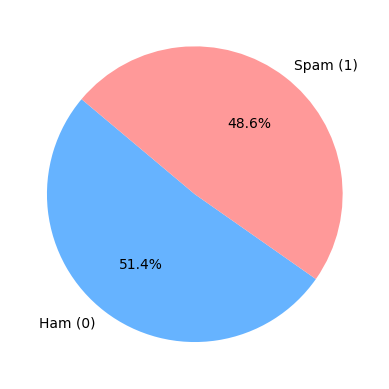

In [11]:
plt.pie(df_all['CLASS'].value_counts(), labels=['Ham (0)', 'Spam (1)'], autopct='%1.1f%%', startangle=140, colors=['#66b3ff','#ff9999'])
plt.show()

In [12]:
df_all["num_chars"] = df_all["CONTENT"].apply(len)
df_all.sample(5)

,CONTENT,CLASS,ARTIST,num_chars
993,At 500 subscribers i&#39;m sky diving help me ...,1,LMFAO,103
628,http://minhateca.com.br/mauro-sp2013/Filmes+Se...,1,KatyPerry,75
220,"Im a RAPPER/SONGWRITER, check my video PLEASE....",1,Psy,106
1038,Check out this video on YouTube:﻿,1,LMFAO,33
408,If she really did this there she's hardcore﻿,0,KatyPerry,44


In [13]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\koksl\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [14]:
# Calculate number of words in each comment by using word tokenization
df_all["num_words"] = df_all["CONTENT"].apply(lambda x: len(nltk.word_tokenize(x))) 
df_all.sample(5)

,CONTENT,CLASS,ARTIST,num_chars,num_words
1493,Hi Guys im an Upcoming Rapper if you could che...,1,Eminem,179,36
1627,I felt old when I realized that this song was ...,0,Shakira,61,15
1774,You guys should check out this EXTRAORDINARY w...,1,Shakira,373,68
1417,COME SUBSCRIBE TO MY CHANNEL! ;-) PLEASE!!,1,Eminem,43,12
1075,Check out my youtube channel for cool beatboxi...,1,LMFAO,52,11


In [15]:
df_all["num_sentences"] = df_all["CONTENT"].apply(lambda x: len(nltk.sent_tokenize(x)))
df_all.sample(5)

,CONTENT,CLASS,ARTIST,num_chars,num_words,num_sentences
359,http://www.twitch.tv/daconnormc﻿,1,KatyPerry,32,3,1
1524,love the you lie the good﻿,0,Eminem,26,6,1
446,"this video is very inaccurate, a tiger would r...",0,KatyPerry,61,13,1
761,Love this song makes me wanna dance! ﻿,0,LMFAO,38,10,2
1838,Hey check out our new musicvideo &#39;&#39;Lif...,1,Shakira,85,32,1


In [16]:
df_all.describe()

,CLASS,num_chars,num_words,num_sentences
count,1956.000000,1956.000000,1956.000000,1956.000000
mean,0.513804,94.700920,21.212679,1.810838
std,0.499937,128.222062,32.558659,2.098350
min,0.000000,2.000000,1.000000,1.000000
25%,0.000000,29.000000,6.000000,1.000000
50%,1.000000,48.000000,10.000000,1.000000
75%,1.000000,97.000000,21.000000,2.000000
max,1.000000,1200.000000,697.000000,25.000000


In [17]:
print("Statistics for Spam (CLASS=1) comments:")
df_all[df_all['CLASS'] == 1].describe()

Statistics for Spam (CLASS=1) comments:


,CLASS,num_chars,num_words,num_sentences
count,1005.0,1005.000000,1005.000000,1005.000000
mean,1.0,137.336318,29.842786,2.215920
std,0.0,158.977404,41.278222,2.731356
min,1.0,10.000000,1.000000,1.000000
25%,1.0,36.000000,8.000000,1.000000
50%,1.0,65.000000,13.000000,1.000000
75%,1.0,171.000000,37.000000,2.000000
max,1.0,1200.000000,697.000000,25.000000


In [18]:
print("Statistics for Ham (CLASS=0) comments:")
df_all[df_all['CLASS'] == 0].describe()

Statistics for Ham (CLASS=0) comments:


,CLASS,num_chars,num_words,num_sentences
count,951.0,951.000000,951.000000,951.000000
mean,0.0,49.644585,12.092534,1.382755
std,0.0,56.284782,14.788682,0.905351
min,0.0,2.000000,1.000000,1.000000
25%,0.0,18.000000,4.000000,1.000000
50%,0.0,34.000000,8.000000,1.000000
75%,0.0,62.000000,15.000000,2.000000
max,0.0,753.000000,193.000000,12.000000


In [19]:
empty_char = len(df_all[df_all["num_chars"] == 0])
print(f"Number of comments with zero characters: {empty_char}")

Number of comments with zero characters: 0


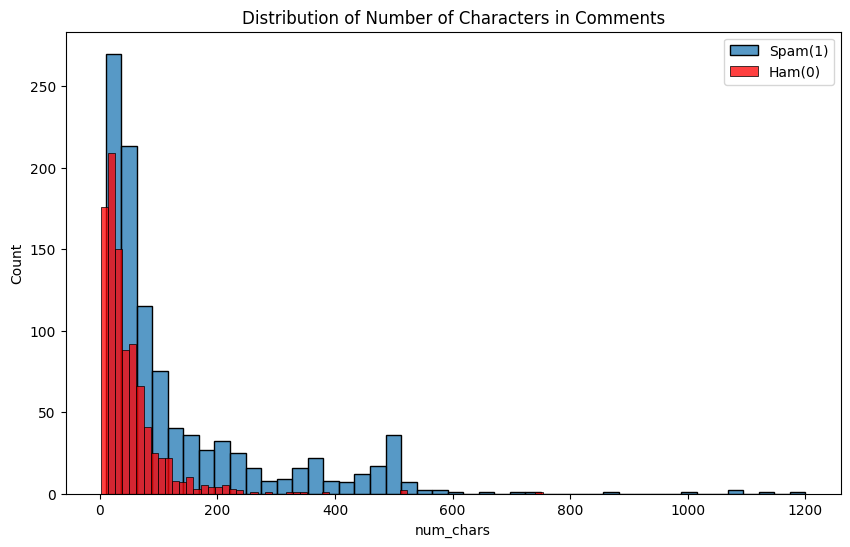

In [20]:
plt.figure(figsize=(10,6))
sns.histplot(data=df_all[df_all["CLASS"]==1]["num_chars"], label="Spam(1)")
sns.histplot(data=df_all[df_all["CLASS"]==0]["num_chars"], color='red', label="Ham(0)")
plt.title("Distribution of Number of Characters in Comments")
plt.legend()
plt.show()

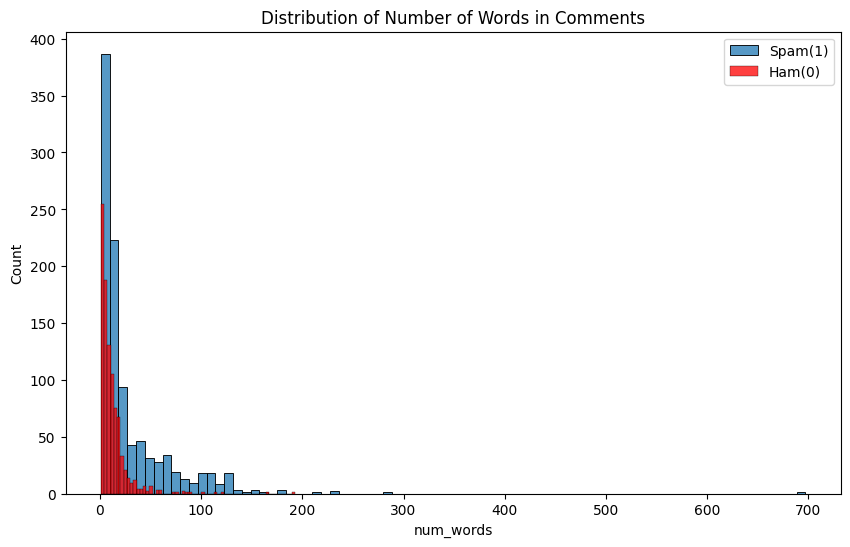

In [21]:
plt.figure(figsize=(10,6))
sns.histplot(data=df_all[df_all["CLASS"]==1]["num_words"], label="Spam(1)", bins=80)
sns.histplot(data=df_all[df_all["CLASS"]==0]["num_words"], color='red', label="Ham(0)", bins=60)
plt.title("Distribution of Number of Words in Comments")
plt.legend()
plt.show()

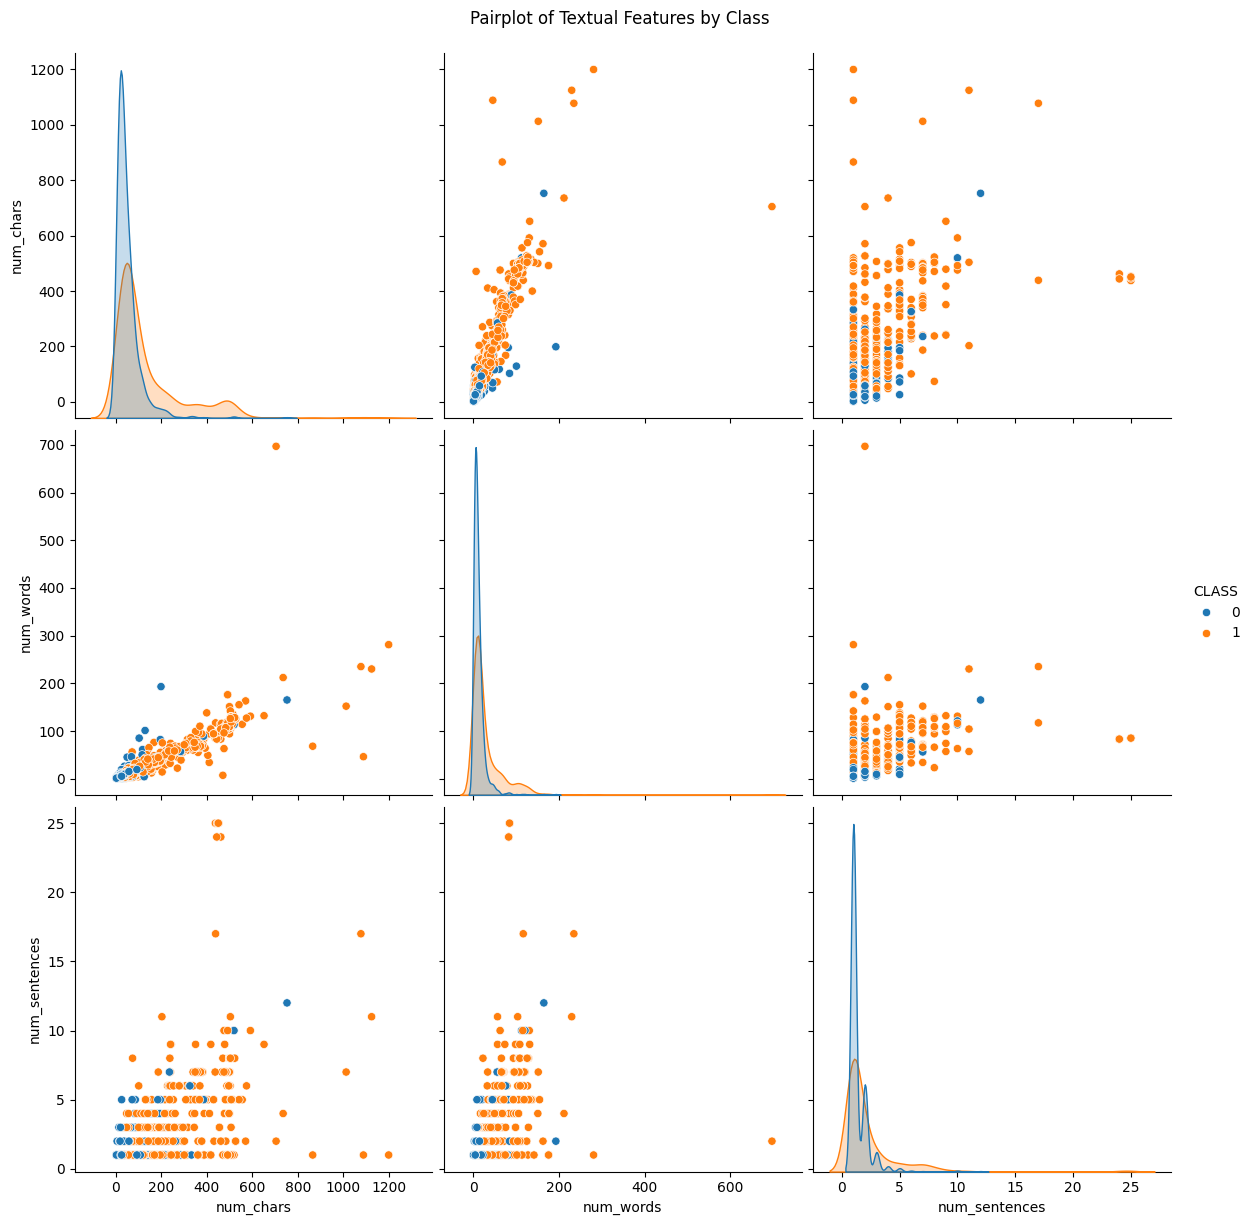

In [22]:
sns.pairplot(data=df_all, hue="CLASS", vars=["num_chars", "num_words", "num_sentences"], height=4)
plt.suptitle("Pairplot of Textual Features by Class", y=1.02)
plt.show()

<Axes: >

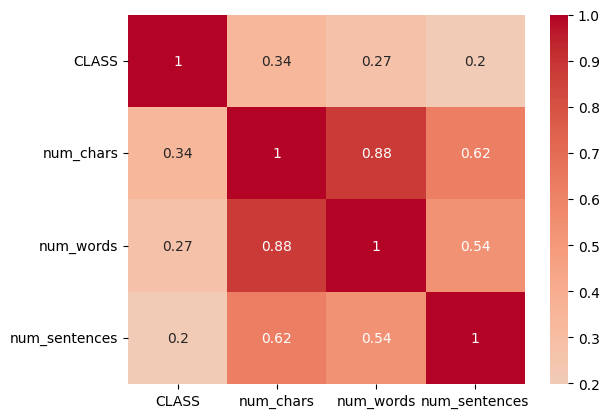

In [23]:
sns.heatmap(df_all.corr(numeric_only=True), annot=True, cmap='coolwarm', center=0)

### Data Preprocessing
- lower case
- tokenization
- removing special characters
- removing stop words
- stemming

In [24]:
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

ps = PorterStemmer()

# 1. Download the stopwords resource
nltk.download('stopwords')

# 2. Get the list of English stop words
stop_words = stopwords.words('english')

string.punctuation

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\koksl\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [25]:
def transform_text(text):
    # Lowercase
    text = text.lower()
    text = nltk.word_tokenize(text)
    remove_special_characters = [char for char in text if char.isalnum()]
    text = remove_special_characters[:]
    remove_special_characters.clear()
    remove_special_characters = [word for word in text if word not in stopwords.words('english') and word not in string.punctuation]

    text = remove_special_characters[:]
    remove_special_characters.clear()
    remove_special_characters = [ps.stem(word) for word in text]

    return ' '.join(remove_special_characters)


In [26]:

df_all["Transformed_TEXT"] = df_all["CONTENT"].apply(transform_text)
df_all.sample(5)

,CONTENT,CLASS,ARTIST,num_chars,num_words,num_sentences,Transformed_TEXT
1101,Check out this video on YouTube:﻿,1,LMFAO,33,8,1,check video youtub
1854,cool,0,Shakira,4,1,1,cool
1122,check it out free stuff for watching videos an...,1,LMFAO,181,39,1,check free stuff watch video fill survey br br...
1029,Check out this playlist on YouTube:hbbhhhgh﻿,1,LMFAO,44,8,1,check playlist youtub
1436,subscribe me if u love eminem,1,Eminem,29,6,1,subscrib u love eminem


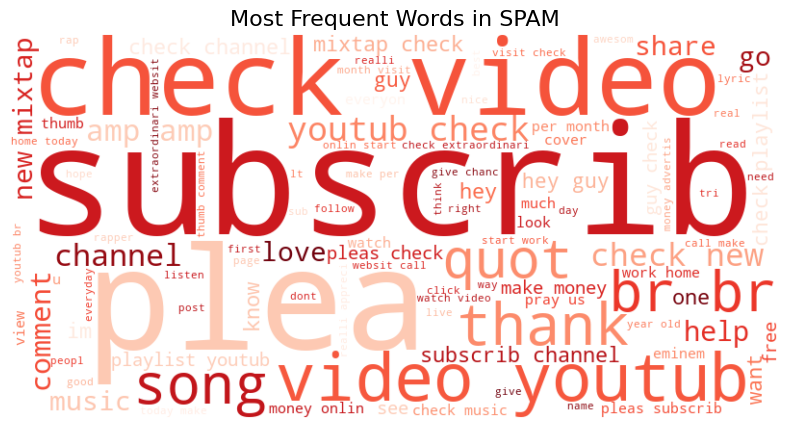

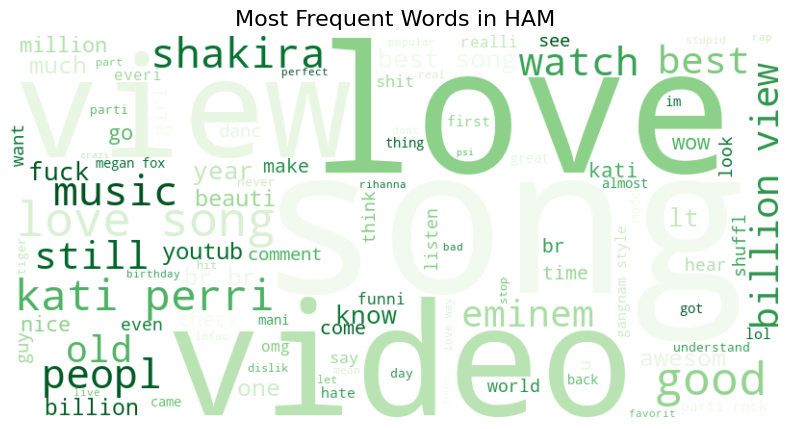

In [27]:
# Split the data into two strings
spam_words = ' '.join(df_all[df_all['CLASS'] == 1]['Transformed_TEXT'])
ham_words = ' '.join(df_all[df_all['CLASS'] == 0]['Transformed_TEXT'])

# Function to generate word clouds
def create_cloud(text, title, color):
    wc = WordCloud(width=800, height=400, background_color='white', colormap=color, max_words=100).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16)
    plt.show()

create_cloud(spam_words, "Most Frequent Words in SPAM", "Reds")
create_cloud(ham_words, "Most Frequent Words in HAM", "Greens")

Total words in SPAM corpus: 12149
Most common words in SPAM corpus:


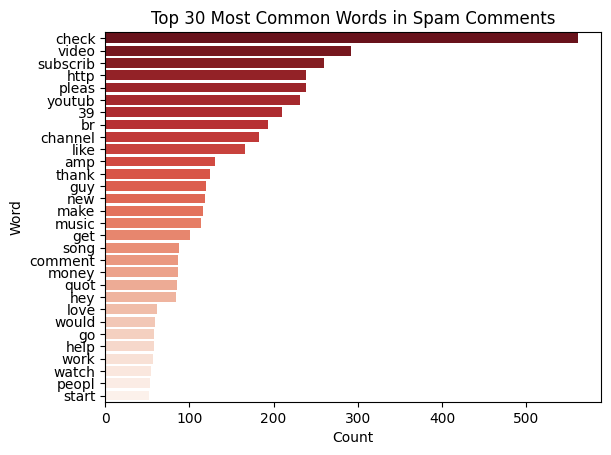

Total words in HAM corpus: 4397
Most common words in HAM corpus:


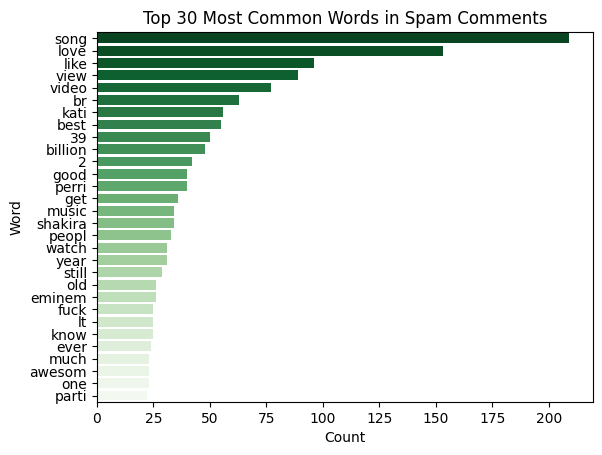

In [28]:
def top_n_words(df, label, n=30):
    corpus = []
    for msg in df[df['CLASS'] == label]['Transformed_TEXT'].tolist():
        for word in msg.split():
            corpus.append(word)
    most_common_words = Counter(corpus).most_common(n)
    print(f"Total words in {'SPAM' if label == 1 else 'HAM'} corpus: {len(corpus)}")
    return most_common_words

def plot_top_n_words(most_common_words, label, palette="Reds_r"):
    print("Most common words in {} corpus:".format("SPAM" if label == 1 else "HAM"))
    # most_common_words looks like: [('word1', count1), ('word2', count2)...]
    df_plot = pd.DataFrame(most_common_words, columns=['Word', 'Count'])
    sns.barplot(x=df_plot['Count'], y=df_plot['Word'], palette=palette)
    plt.title("Top 30 Most Common Words in Spam Comments")
    plt.show()


top_spam_words = top_n_words(df_all, label=1, n=30)
plot_top_n_words(top_spam_words, label=1, palette="Reds_r")

top_ham_words = top_n_words(df_all, label=0, n=30)
plot_top_n_words(top_ham_words, label=0, palette="Greens_r")

### Model Building

In [81]:
from sklearn.preprocessing import MinMaxScaler

def train_test_split(vectorizer, df, test_artist, random_state=42, scalar=False):
    df = df.sample(frac=1, random_state=random_state).reset_index(drop=True)

    train_df = df[df["ARTIST"] != test_artist]
    test_df = df[df["ARTIST"] == test_artist]


    X_train = vectorizer.fit_transform(train_df['Transformed_TEXT']).toarray()
    X_test = vectorizer.transform(test_df['Transformed_TEXT']).toarray()

    if scalar:
        scaler = MinMaxScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

    y_train = train_df['CLASS'].values
    y_test = test_df['CLASS'].values

    print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

    return X_train, y_train, X_test, y_test

In [76]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

def evaluate_model(X_train, y_train, X_test, y_test, artist_name):
    models = [
        XGBClassifier(use_label_encoder=False, eval_metric='logloss'), 
        LGBMClassifier(verbosity=-1), 
        LogisticRegression(max_iter=1000), 
        SVC(kernel='linear'), 
        RandomForestClassifier(n_estimators=100), 
        KNeighborsClassifier(n_neighbors=6)
    ]
    
    results = []

    for model in models:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        results.append({
            'Test_Artist': artist_name,
            'Model': model.__class__.__name__,
            'Accuracy': accuracy_score(y_test, y_pred)
        })
    return results

In [77]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# 1. Define our configurations to test
configs = [
    {'name': 'CountVec', 'vec': CountVectorizer(), 'scale': False},
    {'name': 'CountVec_Scaled', 'vec': CountVectorizer(), 'scale': True},
    {'name': 'TFIDF', 'vec': TfidfVectorizer(), 'scale': False},
    {'name': 'TFIDF_Scaled', 'vec': TfidfVectorizer(), 'scale': True}
]

artists = ['Psy', 'KatyPerry', 'LMFAO', 'Eminem', 'Shakira']
all_results = []

# 2. Outer Loop: Vectorizer/Scaler Combinations
for config in configs:
    print(f"--- Running Experiment: {config['name']} ---")
    
    # 3. Inner Loop: Artists
    for artist in artists:
        # Get data using your existing train_test_split function
        X_train_t, y_train_, X_test_t, y_test_ = train_test_split(
            config['vec'], 
            df_all, 
            artist, 
            random_state=42, 
            scalar=config['scale']
        )
        
        # Evaluate using your modified evaluate_model function
        # (Make sure evaluate_model returns a list of dicts as we discussed)
        artist_results = evaluate_model(X_train_t, y_train_, X_test_t, y_test_, artist)
        
        # Add metadata to each result so we know which config it came from
        for res in artist_results:
            res['Config'] = config['name']
            all_results.append(res)

# 4. Create Master DataFrame
master_results_df = pd.DataFrame(all_results)

--- Running Experiment: CountVec ---
Train size: 1606, Test size: 350
Train size: 1606, Test size: 350
Train size: 1518, Test size: 438
Train size: 1508, Test size: 448
Train size: 1586, Test size: 370
--- Running Experiment: CountVec_Scaled ---
Train size: 1606, Test size: 350
Train size: 1606, Test size: 350
Train size: 1518, Test size: 438
Train size: 1508, Test size: 448
Train size: 1586, Test size: 370
--- Running Experiment: TFIDF ---
Train size: 1606, Test size: 350
Train size: 1606, Test size: 350
Train size: 1518, Test size: 438
Train size: 1508, Test size: 448
Train size: 1586, Test size: 370
--- Running Experiment: TFIDF_Scaled ---
Train size: 1606, Test size: 350
Train size: 1606, Test size: 350
Train size: 1518, Test size: 438
Train size: 1508, Test size: 448
Train size: 1586, Test size: 370


In [80]:
# 1. Calculate the metrics
summary_stats = master_results_df.groupby(['Config', 'Model'])['Accuracy'].agg(['mean', 'std']).reset_index()

# 2. Add the Stability Score (higher means more consistent/stable)
summary_stats['Stability_Score'] = summary_stats['mean'] / (summary_stats['std'] + 1e-9)

# 3. SORT BY STABILITY SCORE (the 'CV-based' ranking)
# We sort by Stability_Score descending so the most reliable model is first
summary_stats = summary_stats.sort_values(by='Stability_Score', ascending=False)

print("Final Model Ranking (Sorted by Stability/CV Score):")
display(summary_stats.style.background_gradient(subset=['mean'], cmap='Greens')
                           .background_gradient(subset=['std'], cmap='Reds_r')
                           .background_gradient(subset=['Stability_Score'], cmap='YlGn')
                           .format({'mean': '{:.4f}', 'std': '{:.4f}', 'Stability_Score': '{:.2f}'}))

Final Model Ranking (Sorted by Stability/CV Score):


,Config,Model,mean,std,Stability_Score
14,TFIDF,LogisticRegression,0.9097,0.0235,38.64
3,CountVec,RandomForestClassifier,0.9115,0.0324,28.17
0,CountVec,KNeighborsClassifier,0.8454,0.0326,25.91
16,TFIDF,SVC,0.9072,0.0353,25.72
20,TFIDF_Scaled,LogisticRegression,0.8919,0.0353,25.24
15,TFIDF,RandomForestClassifier,0.9257,0.0367,25.24
4,CountVec,SVC,0.9204,0.0367,25.09
9,CountVec_Scaled,RandomForestClassifier,0.9115,0.0380,23.98
17,TFIDF,XGBClassifier,0.9203,0.0386,23.86
23,TFIDF_Scaled,XGBClassifier,0.9203,0.0386,23.86


In [82]:
import pandas as pd
import numpy as np
from sklearn.model_selection import LeaveOneGroupOut, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# 1. Define the Pipeline
# This ensures Vectorization and Modeling happen as a single atomic unit
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('logreg', LogisticRegression(max_iter=5000, solver='liblinear'))
])

# 2. Define the Hyperparameter Grid
# We are testing:
# - ngram_range: individual words vs. word pairs (e.g., "check" vs "check out")
# - use_idf: whether to weigh rare words more heavily
# - C: the strength of regularization (lower C = more "strict" model)
param_grid = {
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'tfidf__use_idf': [True, False],
    'tfidf__max_df': [0.7, 0.8, 1.0],
    'logreg__C': [0.1, 1, 10, 100],
    'logreg__penalty': ['l1', 'l2']
}

# 3. Initialize Leave-One-Group-Out (LOAO)
# This uses your 'ARTIST' column to ensure we validate on unseen artists
logo = LeaveOneGroupOut()
groups = df_all['ARTIST']

# 4. Setup GridSearchCV
print("Starting Fine-Tuning... this may take a moment.")
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=logo,
    scoring='accuracy',
    n_jobs=-1,  # Uses all CPU cores
    verbose=1
)

# 5. Execute Search
grid_search.fit(df_all['Transformed_TEXT'], df_all['CLASS'], groups=groups)

# 6. Results Summary
print("\n" + "="*30)
print("FINE-TUNING COMPLETE")
print("="*30)
print(f"Best Artist-Independent Score: {grid_search.best_score_:.4f}")
print("Best Parameters found:")
for param, value in grid_search.best_params_.items():
    print(f"- {param}: {value}")

# 7. Final Model Selection
best_model = grid_search.best_estimator_

Starting Fine-Tuning... this may take a moment.
Fitting 5 folds for each of 96 candidates, totalling 480 fits

FINE-TUNING COMPLETE
Best Artist-Independent Score: 0.9211
Best Parameters found:
- logreg__C: 10
- logreg__penalty: l1
- tfidf__max_df: 0.7
- tfidf__ngram_range: (1, 2)
- tfidf__use_idf: False


In [83]:
# Create a final test split
train_data = df_all[df_all['ARTIST'] != 'Shakira']
test_data = df_all[df_all['ARTIST'] == 'Shakira']

# The best_model is already 'fit', but we re-fit on 4 artists to test on the 5th
best_model.fit(train_data['Transformed_TEXT'], train_data['CLASS'])
y_pred = best_model.predict(test_data['Transformed_TEXT'])

print("\nFinal Performance Report for Shakira (Unseen Artist):")
print(classification_report(test_data['CLASS'], y_pred))


Final Performance Report for Shakira (Unseen Artist):
              precision    recall  f1-score   support

           0       0.88      0.99      0.93       196
           1       0.99      0.85      0.91       174

    accuracy                           0.92       370
   macro avg       0.93      0.92      0.92       370
weighted avg       0.93      0.92      0.92       370



<Figure size 800x600 with 0 Axes>

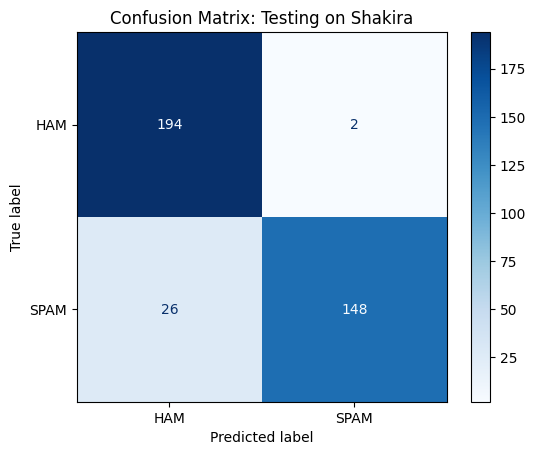

In [84]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm = confusion_matrix(test_data['CLASS'], y_pred)

# Plotting
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['HAM', 'SPAM'])
disp.plot(cmap='Blues', values_format='d')
plt.title(f"Confusion Matrix: Testing on Shakira")
plt.show()

In [85]:
import joblib

# 1. Save the model to a file
# 'compress=3' is a good balance between file size and speed
joblib.dump(best_model, 'youtube_spam_model.pkl', compress=3)
print("Model saved successfully as youtube_spam_model.pkl")

# --- LATER, IN A DIFFERENT SCRIPT OR NOTEBOOK ---

# 2. Load the model back in
loaded_model = joblib.load('youtube_spam_model.pkl')

# 3. Use it to predict a new, custom comment
new_comments = ["Check out my new song! link.com", "I love this artist so much!"]
predictions = loaded_model.predict(new_comments)

for comment, pred in zip(new_comments, predictions):
    print(f"Comment: {comment} | Result: {'SPAM' if pred == 1 else 'HAM'}")

Model saved successfully as youtube_spam_model.pkl
Comment: Check out my new song! link.com | Result: SPAM
Comment: I love this artist so much! | Result: HAM
